In [42]:
import pathlib
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import seaborn as sns
import sys
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
from scipy.stats import wilcoxon

# Global variables
nmedia = 2
nreplicates=3
ring_width = 1

mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['ytick.labelsize'] = 15
mpl.rcParams['axes.titlesize'] = 30

# Colors
colors = list(plt.cm.tab20.colors)
colors += list(plt.cm.tab20b.colors)
all_partners_in_collection = ['At','AeCa','BrVe','CiFr','G3','GN1','GN3','GN4','Ct','G1','G4','G5','G6','G8','AlFa','KlPn','PsFu','PsAe','PsFl','PsPs','PrRe','S1','S2','S5','SC1','SC12','SC14','SC18']
colors = colors[:len(all_partners_in_collection)]
color_dict = dict(zip(all_partners_in_collection, colors))
blues = sns.color_palette("Blues", 5)[1:4]      
oranges = sns.color_palette("Oranges", 5)[1:4]

# Partener subset
partner_subset = ['G3','GN4','Ct','AlFa','G4','PsAe','PsFu','S1']
partner_subset.sort()

# Setup folders 
proj_dir = pathlib.Path("/home/alessia/Documents/PhD/Colony-project")
cfu_dir = proj_dir / 'cfu_counts' / 'raw_data'
if ring_width == 5:
    plot_dir = proj_dir / 'figures' / 'FullData'
elif ring_width == 1:
    plot_dir = proj_dir / 'figures_ring_1' / 'FullData'
if not plot_dir.exists():
    plot_dir.mkdir(parents=True)
   
# Import functions
sys.path.insert(0, str(proj_dir / 'code'))
from _cfu_analysis_functions import *

## Load cfu and image analysis data for FA

In [43]:
# Load cfu and image analysis data for FA
all_cfu_files = glob.glob(str(cfu_dir / '*SET*'))
cfu_df = pd.read_excel(all_cfu_files[0])
for file in all_cfu_files[1:]:
    cfu_df2 = pd.read_excel(file)
    cfu_df = pd.concat([cfu_df,cfu_df2])
cfu_df.reset_index(drop=True,inplace=True)
cfu_df = cfu_df[cfu_df['partner'] != "OaWT"]
cfu_df = cfu_df[cfu_df['strain'] != "OaWT"]
cfu_df = cfu_df[cfu_df['condition'] != "FA-control"]
cfu_df = cfu_df[cfu_df['condition'] != "FA-border"]
cfu_df = cfu_df[cfu_df['condition'] != "FAT-border"].copy()

In [44]:
# Create a dataframe containing a row for each partner and condition, and having as columns the effect of partner on Oa, te effect of Oa on partner, and the partner monoculure yield
partners_fa = pd.unique(cfu_df[cfu_df['culture']=="co"]['partner'])
partners_fa = [p for p in partners_fa if p != "Oa"]
rows = []
for partner in partners_fa:
    for media in ['FAT','FA']:
        mean_oa_on_p = np.mean([get_oa_on_p(cfu_df, media, partner, rep) for rep in range(1, nreplicates + 1)])
        mean_p_on_oa = np.mean([get_p_on_oa(cfu_df, media, partner, rep) for rep in range(1, nreplicates + 1)])
        mean_p_yield = np.mean([get_p_yield(cfu_df, media, partner, rep) for rep in range(1, nreplicates + 1)])
        mean_oa_yield = np.mean([get_oa_yield(cfu_df, media, rep) for rep in range(1, nreplicates + 1)])
        thiamin = 1 if media == 'FAT' else 0
        rows.append({'partner':partner,'carbon_source':'FA', 'salt':1 ,'thiamin':thiamin,'oa_on_p':mean_oa_on_p,'p_on_oa':mean_p_on_oa,'p_yield':mean_p_yield,'oa_yield':mean_oa_yield})
mean_cfu_values_fa = pd.DataFrame(rows)
mean_cfu_values_fa.head()   

,partner,carbon_source,salt,thiamin,oa_on_p,p_on_oa,p_yield,oa_yield
0,G3,FA,1,1,-1.136132,-0.078633,4.690683,5.261825
1,G3,FA,1,0,-0.107521,1.198228,4.715451,2.897085
2,G4,FA,1,1,-0.292130,-0.179218,4.678522,5.261825
3,G4,FA,1,0,-0.247449,2.107227,4.740780,2.897085
4,G5,FA,1,1,-1.589284,-0.042213,4.444079,5.261825


In [45]:
# Load image analysis data
if ring_width == 5:
    data_fa = pd.read_csv('../AllSets_FA/fa_image_analysis.csv')
elif ring_width == 1:
    data_fa = pd.read_csv('../AllSets_FA/fa_image_analysis_ring_1.csv')

In [46]:
# Create a dataframe containing a row for each partner and condition, and having as columns the mean mixing, mean Oa frequency, mean Oa sector size and mean partner sector size
data_fa_mean = data_fa.groupby(['partner','media']).agg({'mean_intermixing':'mean','oa_frequency':'mean','sector_size_Oa':'mean','sector_size_partner':'mean'}).reset_index()
data_fa_mean["carbon_source"] = "FA"
data_fa_mean["salt"] = 1
data_fa_mean["thiamin"] = data_fa_mean["media"].apply(lambda x: 1 if x == "FAT" else 0)
data_fa_mean.drop(columns=['media'], inplace=True)
data_fa_mean.head()

,partner,mean_intermixing,oa_frequency,sector_size_Oa,sector_size_partner,carbon_source,salt,thiamin
0,AeCa,0.040726,0.851525,315.639676,14.312528,FA,1,0
1,AeCa,0.022029,0.873968,560.872303,30.340567,FA,1,1
2,AlFa,0.041917,0.044120,10.564428,259.867420,FA,1,0
3,AlFa,0.048206,0.101305,10.355990,114.458219,FA,1,1
4,At,0.026206,0.619387,46.660707,28.270693,FA,1,0


In [47]:
# Merge the two dataframes
data_fa = pd.merge(data_fa_mean, mean_cfu_values_fa, on=['partner','carbon_source','salt','thiamin'], how='inner')
print(f"Number of rows in FA data: {len(data_fa)}")
del cfu_df, mean_cfu_values_fa, data_fa_mean
data_fa.head()

Number of rows in FA data: 56


,partner,mean_intermixing,oa_frequency,sector_size_Oa,sector_size_partner,carbon_source,salt,thiamin,oa_on_p,p_on_oa,p_yield,oa_yield
0,AeCa,0.040726,0.851525,315.639676,14.312528,FA,1,0,-0.272455,1.828995,3.591593,2.897085
1,AeCa,0.022029,0.873968,560.872303,30.340567,FA,1,1,-1.074822,-0.329101,3.466486,5.261825
2,AlFa,0.041917,0.044120,10.564428,259.867420,FA,1,0,-0.075283,0.756027,5.449509,2.897085
3,AlFa,0.048206,0.101305,10.355990,114.458219,FA,1,1,-0.060629,-1.271853,5.447067,5.261825
4,At,0.026206,0.619387,46.660707,28.270693,FA,1,0,-0.111893,1.556439,4.550016,2.897085


## Load cfu and image analysis data for FAns


In [48]:
# Load cfu and image analysis data for FAns
remove_psae = True
remove_alfa = False
# CFU counts
cfu_df = pd.read_csv(cfu_dir / '20260602_NOSALT.csv')
# remove PsAe from the data
if remove_psae:
    cfu_df = cfu_df[(cfu_df["strain"]!="PsAe")&(cfu_df["partner"] != "PsAe")]
if remove_alfa:
    cfu_df = cfu_df[(cfu_df["strain"]!="AlFa")&(cfu_df["partner"] != "AlFa")]

# Load image analysis data
if ring_width == 5:
    data_im = pd.read_csv('../20260601_D5_NOSALT/fa_ns_image_analysis.csv')
elif ring_width == 1:
    data_im = pd.read_csv('../20260601_D5_NOSALT/fa_ns_image_analysis_ring_1.csv')
# rmove PsAe from the data
if remove_psae:
    data_im = data_im[(data_im["partner"]!="PsAe")]
if remove_alfa:
    data_im = data_im[(data_im["partner"]!="AlFa")]

In [49]:
# Create a dataframe containing a row for each partner and condition, and having as columns the effect of partner on Oa, te effect of Oa on partner, and the partner monoculure yield
partners_fa_ns = pd.unique(cfu_df[cfu_df['culture']=="co"]['partner'])
partners_fa_ns = [p for p in partners_fa_ns if p != "Oa"]
rows = []
for partner in partners_fa_ns:
    for media in ['FAT_ns','FA_ns']:
        mean_oa_on_p = np.mean([get_oa_on_p(cfu_df, media, partner, rep) for rep in range(1, nreplicates + 1)])
        mean_p_on_oa = np.mean([get_p_on_oa(cfu_df, media, partner, rep) for rep in range(1, nreplicates + 1)])
        mean_p_yield = np.mean([get_p_yield(cfu_df, media, partner, rep) for rep in range(1, nreplicates + 1)])
        mean_oa_yield = np.mean([get_oa_yield(cfu_df, media, rep) for rep in range(1, nreplicates + 1)])
        thiamin = 1 if media == 'FAT_ns' else 0
        rows.append({'partner':partner,'carbon_source':'FA', 'salt':0 ,'thiamin':thiamin,'oa_on_p':mean_oa_on_p,'p_on_oa':mean_p_on_oa,'p_yield':mean_p_yield,'oa_yield':mean_oa_yield})
mean_cfu_values = pd.DataFrame(rows)
mean_cfu_values.head()  

,partner,carbon_source,salt,thiamin,oa_on_p,p_on_oa,p_yield,oa_yield
0,G3,FA,0,1,0.059551,-1.012328,4.515729,5.195017
1,G3,FA,0,0,0.089462,1.055796,4.589989,2.949507
2,GN4,FA,0,1,-0.279398,-0.359845,4.211400,5.195017
3,GN4,FA,0,0,-0.070593,1.687781,4.198843,2.949507
4,Ct,FA,0,1,0.127114,-1.043032,5.747640,5.195017


In [50]:
# Create a dataframe containing a row for each partner and condition, and having as columns the mean mixing, mean Oa frequency, mean Oa sector size and mean partner sector size
data_im_mean = data_im.groupby(['partner','media']).agg({'mean_intermixing':'mean','oa_frequency':'mean','sector_size_Oa':'mean','sector_size_partner':'mean'}).reset_index()
data_im_mean["carbon_source"] = "FA"
data_im_mean["salt"] = 0
data_im_mean["thiamin"] = data_im_mean["media"].apply(lambda x: 1 if x == "FAT_ns" else 0)
data_im_mean.drop(columns=['media'], inplace=True)
data_im_mean.head()

,partner,mean_intermixing,oa_frequency,sector_size_Oa,sector_size_partner,carbon_source,salt,thiamin
0,AlFa,0.042198,0.042928,8.154820,559.362697,FA,0,1
1,AlFa,0.041544,0.028038,7.354335,582.947325,FA,0,0
2,Ct,0.090758,0.205172,12.274609,51.357464,FA,0,1
3,Ct,0.091989,0.249912,13.015860,41.279648,FA,0,0
4,G3,0.026686,0.068897,24.627466,578.324565,FA,0,1


In [51]:
# Merge the two dataframes
data_fa_ns = pd.merge(data_im_mean, mean_cfu_values, on=['partner','carbon_source','salt','thiamin'], how='inner')
print(f"Number of rows in FA NS data: {len(data_fa_ns)}")
del cfu_df, mean_cfu_values, data_im_mean
data_fa_ns.head()

Number of rows in FA NS data: 14


,partner,mean_intermixing,oa_frequency,sector_size_Oa,sector_size_partner,carbon_source,salt,thiamin,oa_on_p,p_on_oa,p_yield,oa_yield
0,AlFa,0.042198,0.042928,8.154820,559.362697,FA,0,1,-0.072541,-2.397295,5.392253,5.195017
1,AlFa,0.041544,0.028038,7.354335,582.947325,FA,0,0,-0.041240,-0.589710,5.323625,2.949507
2,Ct,0.090758,0.205172,12.274609,51.357464,FA,0,1,0.127114,-1.043032,5.747640,5.195017
3,Ct,0.091989,0.249912,13.015860,41.279648,FA,0,0,-0.019391,1.297927,5.868844,2.949507
4,G3,0.026686,0.068897,24.627466,578.324565,FA,0,1,0.059551,-1.012328,4.515729,5.195017


## Load cfu and image analysis data for Glu


In [52]:
# Load cfu and image analysis data for Glu
remove_psae = True
remove_g3 = True
# CFU counts
cfu_df = pd.read_csv(cfu_dir / '20260616_GLUCOSE.csv')
# remove PsAe from the data
if remove_psae:
    cfu_df = cfu_df[(cfu_df["strain"]!="PsAe")&(cfu_df["partner"] != "PsAe")]
if remove_g3:
    cfu_df = cfu_df[(cfu_df["strain"]!="G3")&(cfu_df["partner"] != "G3")]

# Load image analysis data
if ring_width == 5:
    data_im = pd.read_csv('../20260615_D5_GLUCOSE/glu_image_analysis.csv')
elif ring_width == 1:
    data_im = pd.read_csv('../20260615_D5_GLUCOSE/glu_image_analysis_ring_1.csv')
# remove PsAe from the data
if remove_psae:
    data_im = data_im[(data_im["partner"]!="PsAe")]
if remove_g3:
    data_im = data_im[(data_im["partner"]!="G3")]

In [53]:
# Create a dataframe containing a row for each partner and condition, and having as columns the effect of partner on Oa, te effect of Oa on partner, and the partner monoculure yield
partners_glu = pd.unique(cfu_df[cfu_df['culture']=="co"]['partner'])
partners_glu = [p for p in partners_glu if p != "Oa"]
rows = []
for partner in partners_glu:
    for media in ['GluT','Glu']:
        mean_oa_on_p = np.mean([get_oa_on_p(cfu_df, media, partner, rep) for rep in range(1, nreplicates + 1)])
        mean_p_on_oa = np.mean([get_p_on_oa(cfu_df, media, partner, rep) for rep in range(1, nreplicates + 1)])
        mean_p_yield = np.mean([get_p_yield(cfu_df, media, partner, rep) for rep in range(1, nreplicates + 1)])
        mean_oa_yield = np.mean([get_oa_yield(cfu_df, media, rep) for rep in range(1, nreplicates + 1)])
        thiamin = 1 if media == 'GluT' else 0
        rows.append({'partner':partner,'carbon_source':'Glu', 'salt':1 ,'thiamin':thiamin,'oa_on_p':mean_oa_on_p,'p_on_oa':mean_p_on_oa,'p_yield':mean_p_yield,'oa_yield':mean_oa_yield})
mean_cfu_values = pd.DataFrame(rows)
mean_cfu_values.head()  

,partner,carbon_source,salt,thiamin,oa_on_p,p_on_oa,p_yield,oa_yield
0,GN4,Glu,1,1,-0.576058,-0.335635,4.432475,5.668867
1,GN4,Glu,1,0,-0.315657,1.630492,4.402639,3.404312
2,Ct,Glu,1,1,-0.474880,-0.189696,2.344567,5.668867
3,Ct,Glu,1,0,1.679609,0.855085,2.309117,3.404312
4,G4,Glu,1,1,-0.065317,-1.054586,4.749774,5.668867


In [54]:
# Create a dataframe containing a row for each partner and condition, and having as columns the mean mixing, mean Oa frequency, mean Oa sector size and mean partner sector size
data_im_mean = data_im.groupby(['partner','media']).agg({'mean_intermixing':'mean','oa_frequency':'mean','sector_size_Oa':'mean','sector_size_partner':'mean'}).reset_index()
data_im_mean["carbon_source"] = "Glu"
data_im_mean["salt"] = 1
data_im_mean["thiamin"] = data_im_mean["media"].apply(lambda x: 1 if x == "GluT" else 0)
data_im_mean.drop(columns=['media'], inplace=True)
data_im_mean.head()

,partner,mean_intermixing,oa_frequency,sector_size_Oa,sector_size_partner,carbon_source,salt,thiamin
0,AlFa,0.247546,0.907684,140.007824,6.406385,Glu,1,0
1,AlFa,0.000000,0.998384,1656.618665,4.289181,Glu,1,1
2,Ct,0.128005,0.877124,93.976829,9.476607,Glu,1,0
3,Ct,0.000000,0.999321,1176.677389,1.680351,Glu,1,1
4,G4,0.128146,0.447705,13.819286,17.543012,Glu,1,0


In [55]:
# Merge the two dataframes
data_glu = pd.merge(data_im_mean, mean_cfu_values, on=['partner','carbon_source','salt','thiamin'], how='inner')
print(f"Number of rows in Glu data: {len(data_glu)}")
del cfu_df, mean_cfu_values, data_im_mean
data_glu.head()

Number of rows in Glu data: 12


,partner,mean_intermixing,oa_frequency,sector_size_Oa,sector_size_partner,carbon_source,salt,thiamin,oa_on_p,p_on_oa,p_yield,oa_yield
0,AlFa,0.247546,0.907684,140.007824,6.406385,Glu,1,0,0.824488,2.066278,4.120716,3.404312
1,AlFa,0.000000,0.998384,1656.618665,4.289181,Glu,1,1,-0.985392,-0.143269,4.107176,5.668867
2,Ct,0.128005,0.877124,93.976829,9.476607,Glu,1,0,1.679609,0.855085,2.309117,3.404312
3,Ct,0.000000,0.999321,1176.677389,1.680351,Glu,1,1,-0.474880,-0.189696,2.344567,5.668867
4,G4,0.128146,0.447705,13.819286,17.543012,Glu,1,0,-0.037653,1.016367,4.684226,3.404312


## Create complete dataframe

In [56]:
data_full = pd.concat([data_fa, data_fa_ns, data_glu])
carbon_source_mapping = {'FA':0,'Glu':1}
data_full['carbon_source'] = data_full['carbon_source'].map(carbon_source_mapping)
data_full["log_sector"] = np.log(data_full["sector_size_Oa"])
data_full.head()

,partner,mean_intermixing,oa_frequency,sector_size_Oa,sector_size_partner,carbon_source,salt,thiamin,oa_on_p,p_on_oa,p_yield,oa_yield,log_sector
0,AeCa,0.040726,0.851525,315.639676,14.312528,0,1,0,-0.272455,1.828995,3.591593,2.897085,5.754601
1,AeCa,0.022029,0.873968,560.872303,30.340567,0,1,1,-1.074822,-0.329101,3.466486,5.261825,6.329493
2,AlFa,0.041917,0.044120,10.564428,259.867420,0,1,0,-0.075283,0.756027,5.449509,2.897085,2.357493
3,AlFa,0.048206,0.101305,10.355990,114.458219,0,1,1,-0.060629,-1.271853,5.447067,5.261825,2.337565
4,At,0.026206,0.619387,46.660707,28.270693,0,1,0,-0.111893,1.556439,4.550016,2.897085,3.842902


In [57]:
# Divide interactions between faiclitation and competition
data_full['oa_on_p_facilitation'] = data_full['oa_on_p'].apply(lambda x: x if x > 0.1 else 0)
data_full['oa_on_p_competition'] = data_full['oa_on_p'].apply(lambda x: x if x < -0.1 else 0)
data_full['p_on_oa_facilitation'] = data_full['p_on_oa'].apply(lambda x: x if x > 0.1 else 0)
data_full['p_on_oa_competition'] = data_full['p_on_oa'].apply(lambda x: x if x < -0.1 else 0)

## Comparison of Oa sector sizes

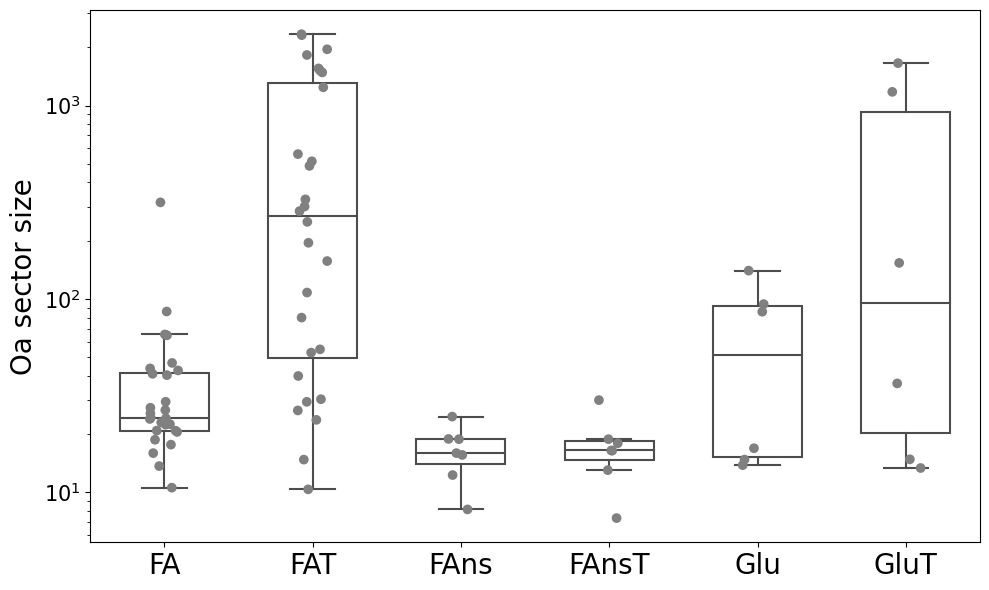

In [58]:
plot_data = data_full.copy()

plot_data["condition"] = (
    plot_data["carbon_source"].astype(str)
    + " | salt="
    + plot_data["salt"].astype(str)
    + " | thiamin="
    + plot_data["thiamin"].astype(str)
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.stripplot(
    data=plot_data,
    x="condition",
    y="sector_size_Oa",
    ax=ax,
    color="gray",
    size=7
)

sns.boxplot(
    data=plot_data,
    x="condition",
    y="sector_size_Oa",
    color="gray",
    width=0.6,
    fliersize=0,
    boxprops={'facecolor':'none'},
    showfliers=False,
    ax=ax
)

ax.set_xticks([0,1,2,3,4,5])
ax.set_xticklabels(["FA", "FAT", "FAns","FAnsT","Glu","GluT"])
ax.set_xlabel("")
ax.set_ylabel("Oa sector size")
ax.set_yscale("log")
plt.tight_layout()
plt.savefig(plot_dir / "full_oa_sector_size.png", dpi=300)
plt.show()

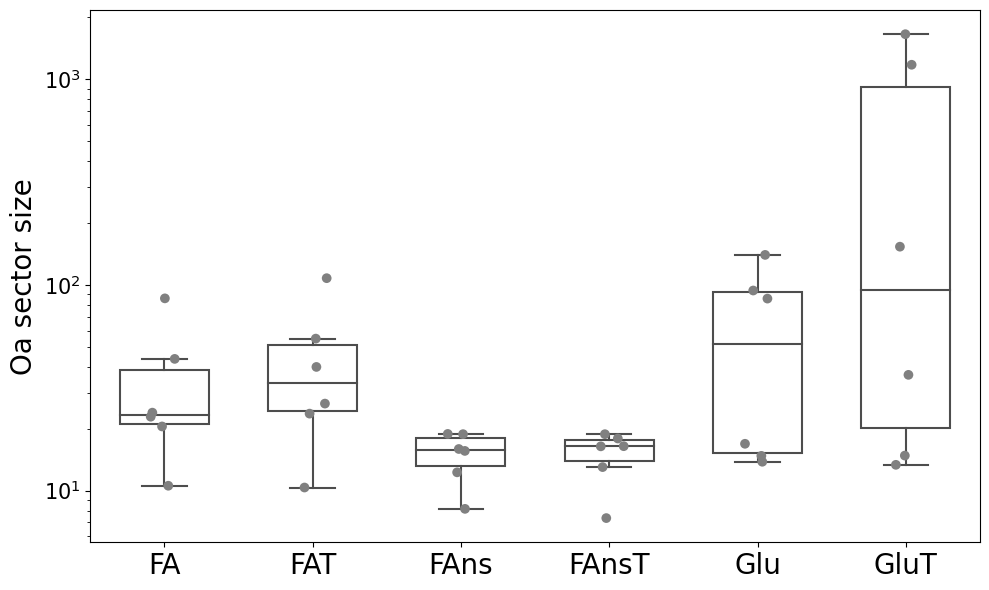

In [59]:
plot_data = data_full[data_full["partner"].isin(partner_subset)].copy()
# remove psae and g3 from the data
plot_data = plot_data[(plot_data["partner"]!="PsAe")&(plot_data["partner"]!="G3")].copy()

plot_data["condition"] = (
    plot_data["carbon_source"].astype(str)
    + " | salt="
    + plot_data["salt"].astype(str)
    + " | thiamin="
    + plot_data["thiamin"].astype(str)
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.stripplot(
    data=plot_data,
    x="condition",
    y="sector_size_Oa",
    ax=ax,
    color="gray",
    size=7
)

sns.boxplot(
    data=plot_data,
    x="condition",
    y="sector_size_Oa",
    color="gray",
    width=0.6,
    fliersize=0,
    boxprops={'facecolor':'none'},
    showfliers=False,
    ax=ax
)

ax.set_xticks([0,1,2,3,4,5])
ax.set_xticklabels(["FA", "FAT", "FAns","FAnsT","Glu","GluT"])
ax.set_xlabel("")
ax.set_ylabel("Oa sector size")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

In [60]:
oa_fa = plot_data[(plot_data["carbon_source"]==0)&(plot_data["salt"]==1)&(plot_data["thiamin"]==0)]["sector_size_Oa"]
oa_fat = plot_data[(plot_data["carbon_source"]==0)&(plot_data["salt"]==1)&(plot_data["thiamin"]==1)]["sector_size_Oa"]
oa_fa_ns = plot_data[(plot_data["carbon_source"]==0)&(plot_data["salt"]==0)&(plot_data["thiamin"]==0)]["sector_size_Oa"]
oa_fat_ns = plot_data[(plot_data["carbon_source"]==0)&(plot_data["salt"]==0)&(plot_data["thiamin"]==1)]["sector_size_Oa"]
oa_glu = plot_data[(plot_data["carbon_source"]==1)&(plot_data["salt"]==1)&(plot_data["thiamin"]==0)]["sector_size_Oa"]
oa_glu_glut = plot_data[(plot_data["carbon_source"]==1)&(plot_data["salt"]==1)&(plot_data["thiamin"]==1)]["sector_size_Oa"]

conditions = ["fa","fat","fa_ns", "fat_ns", "glu", "glut"]
all_oa = [oa_fa, oa_fat, oa_fa_ns, oa_fat_ns, oa_glu, oa_glu_glut]

import itertools

all_pvalues = []
for comparison in itertools.combinations(conditions, 2):
    x = all_oa[conditions.index(comparison[0])]
    y = all_oa[conditions.index(comparison[1])]
    res = wilcoxon(x, y)
    all_pvalues.append(res.pvalue)
    print(f"{comparison}: stat={res.statistic}, p-value={res.pvalue}")

('fa', 'fat'): stat=6.0, p-value=0.4375
('fa', 'fa_ns'): stat=0.0, p-value=0.03125
('fa', 'fat_ns'): stat=0.0, p-value=0.03125
('fa', 'glu'): stat=10.0, p-value=1.0
('fa', 'glut'): stat=4.0, p-value=0.21875
('fat', 'fa_ns'): stat=0.0, p-value=0.03125
('fat', 'fat_ns'): stat=0.0, p-value=0.03125
('fat', 'glu'): stat=8.0, p-value=0.6875
('fat', 'glut'): stat=5.0, p-value=0.3125
('fa_ns', 'fat_ns'): stat=10.0, p-value=1.0
('fa_ns', 'glu'): stat=6.0, p-value=0.4375
('fa_ns', 'glut'): stat=3.0, p-value=0.15625
('fat_ns', 'glu'): stat=6.0, p-value=0.4375
('fat_ns', 'glut'): stat=3.0, p-value=0.15625
('glu', 'glut'): stat=2.0, p-value=0.09375


## Visual inspection of variable correlations

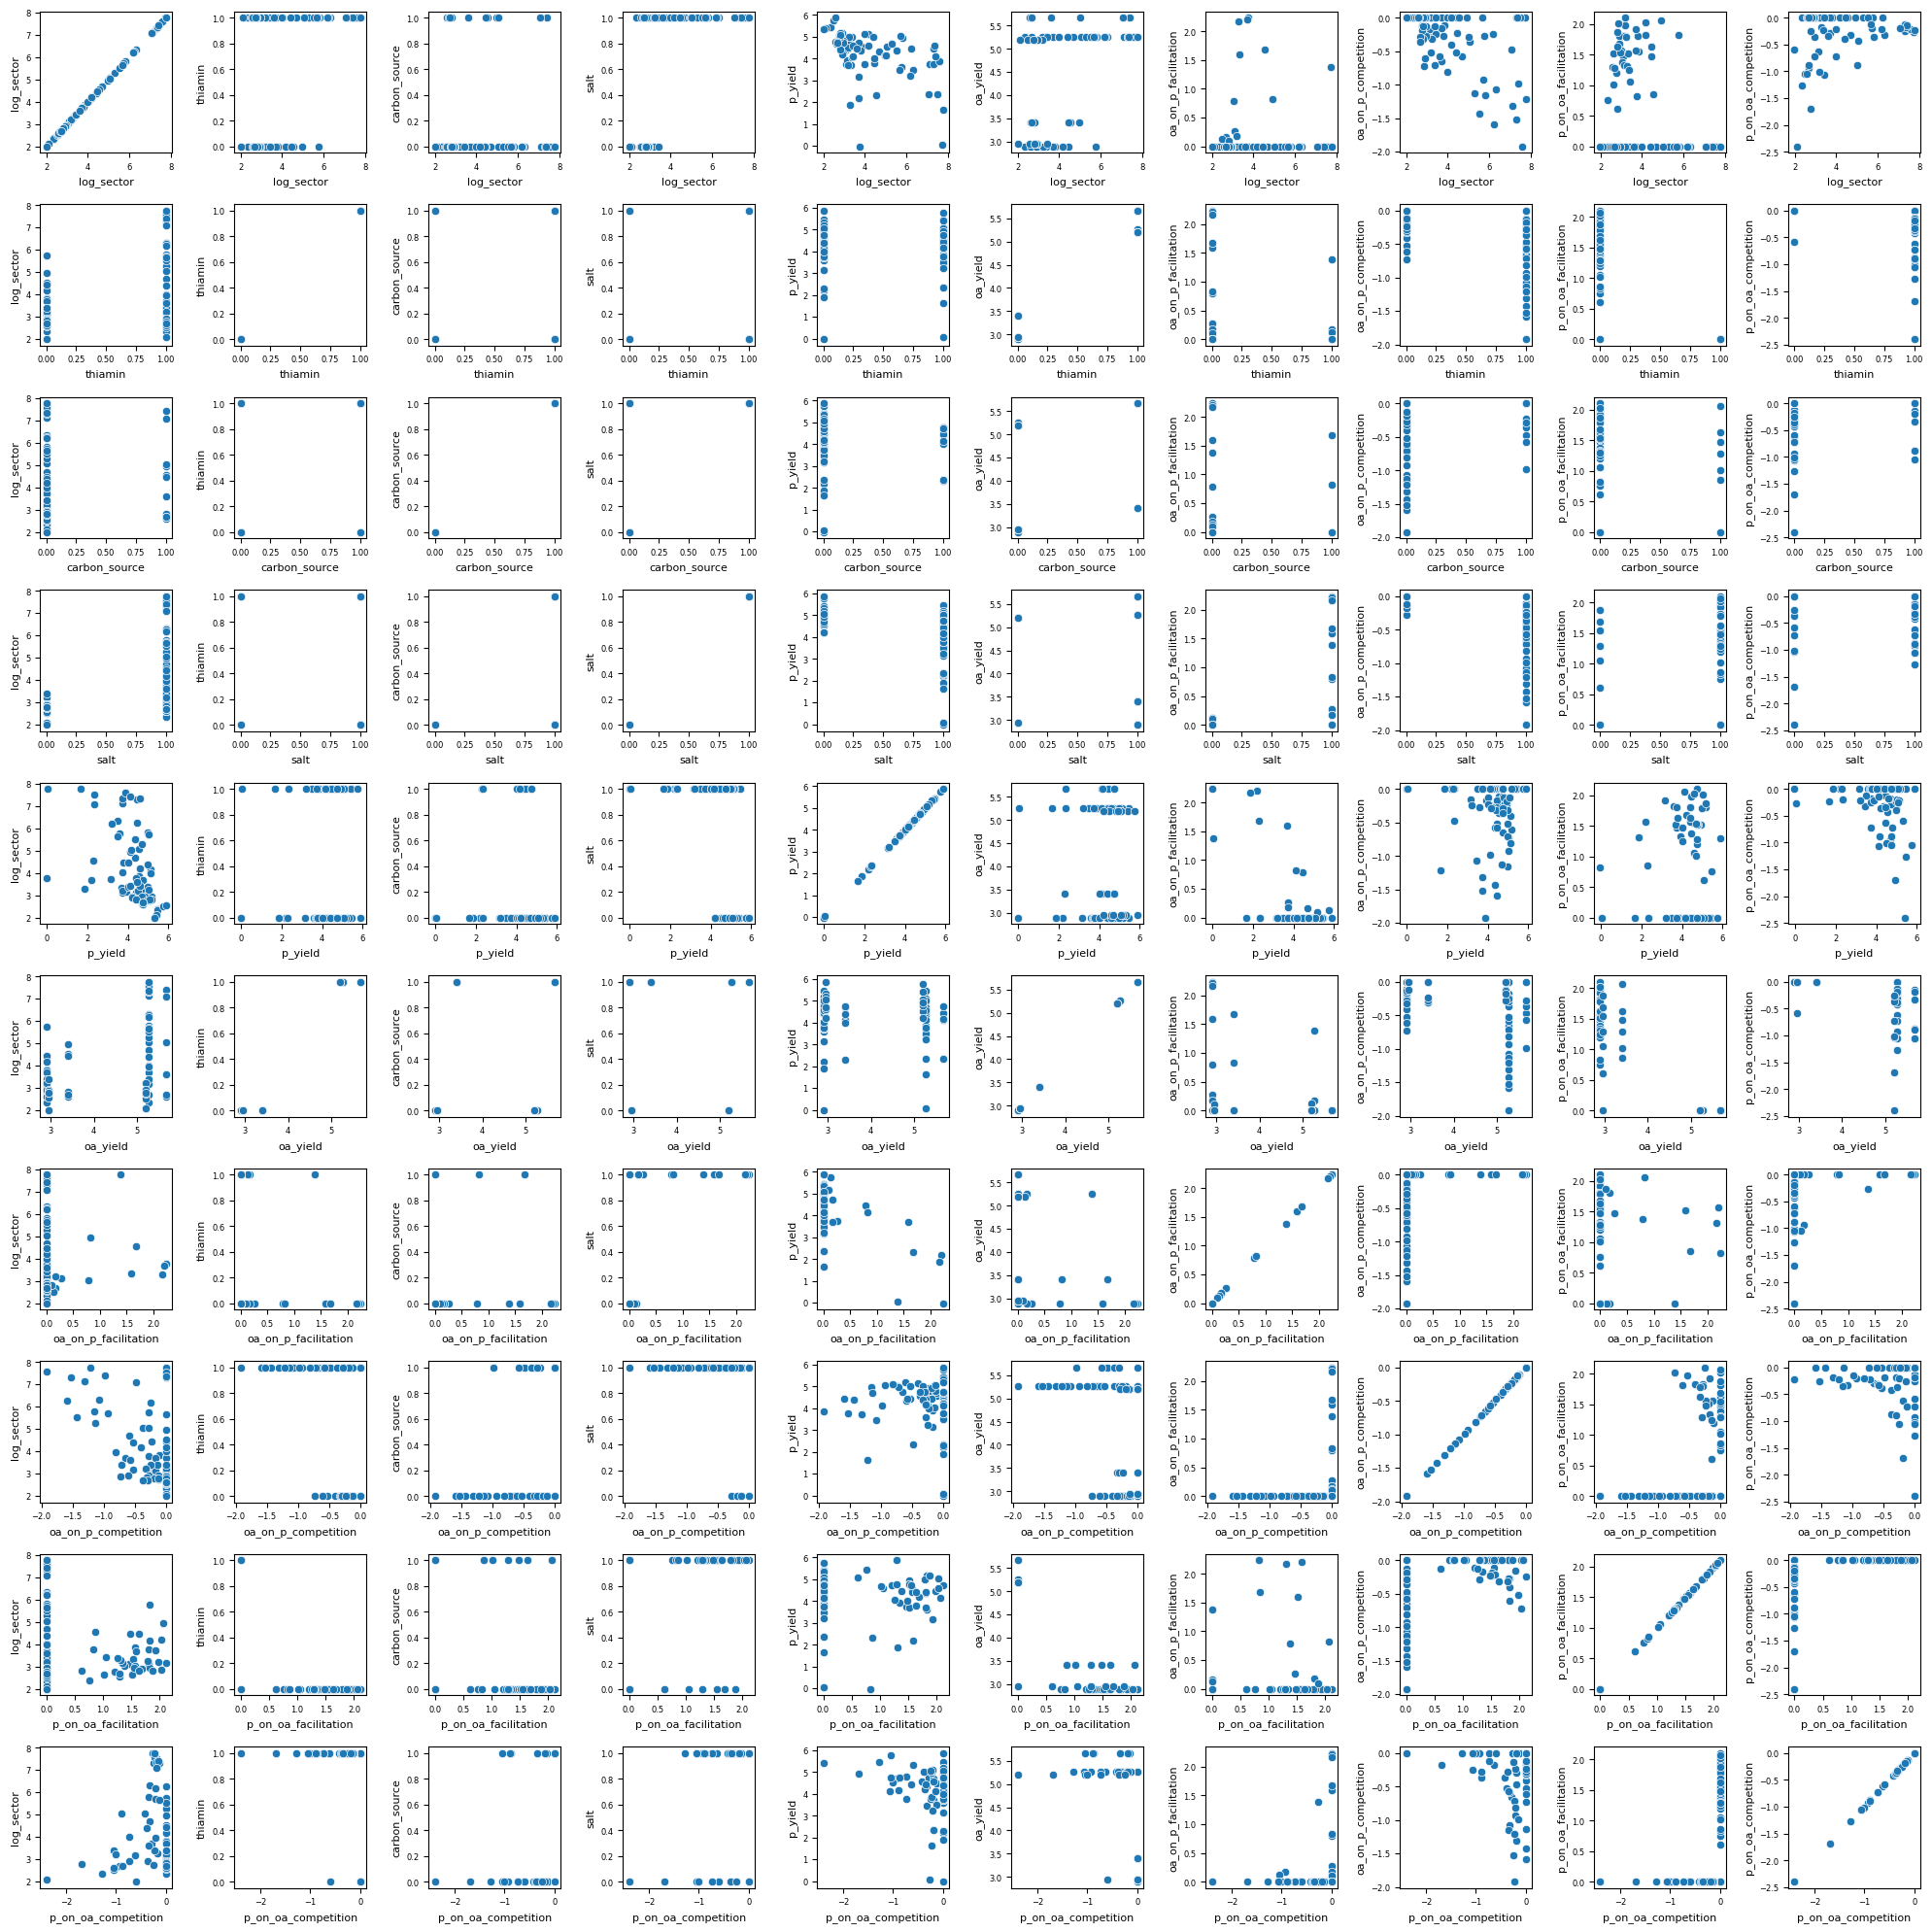

In [61]:
# Plot 9x9 grid of correlations between all variables
fig, axs = plt.subplots(ncols=10,nrows=10, figsize=(20, 20))
param_order = ['log_sector','thiamin','carbon_source','salt','p_yield','oa_yield','oa_on_p_facilitation','oa_on_p_competition','p_on_oa_facilitation','p_on_oa_competition']
param_combinations = [(i, j) for i in range(len(param_order)) for j in range(len(param_order))]
for i, ax in enumerate(axs.flatten()):
    params = param_combinations[i]
    sns.scatterplot(data=data_full, x=param_order[params[0]], y=param_order[params[1]], ax=ax)
    ax.set_xlabel(param_order[params[0]],fontsize=8)
    ax.set_ylabel(param_order[params[1]],fontsize=8)
    ax.tick_params(axis='both', which='major', labelsize=6)
plt.tight_layout()
plt.show()

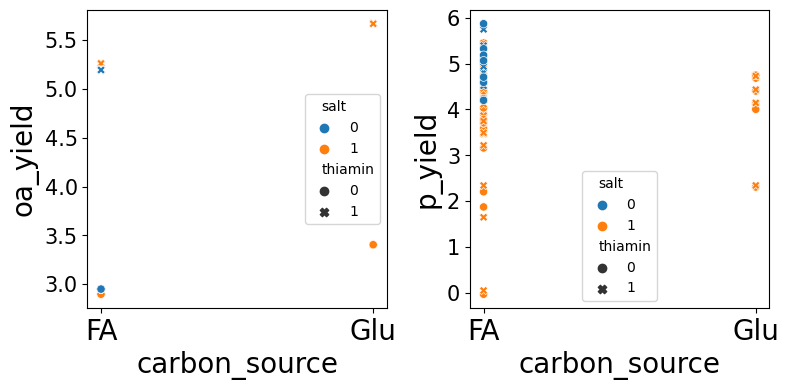

In [62]:
fig, axs = plt.subplots(ncols=2,nrows=1, figsize=(8, 4))
sns.scatterplot(data=data_full, x='carbon_source', y='oa_yield',hue='salt',style='thiamin',ax=axs[0])
sns.scatterplot(data=data_full, x='carbon_source', y='p_yield',hue='salt',style='thiamin',ax=axs[1])
for i in range(2):
    axs[i].set_xticks([0,1])
    axs[i].set_xticklabels(['FA','Glu'])
plt.tight_layout()
plt.show()

## Model with environmental quantities only: model_env

For the linear models fit the log transformed average Oa sector size for each partner. <br> Then, to get effect of partner, use all replicates and compared with a mixed model. <br> Note that data_full already has the averages!

In [63]:
# Fit a linear model to predict log_sector based on carbon_source, salt, and thiamin
model_env = smf.ols(
    "log_sector ~ C(carbon_source) + C(salt) + C(thiamin)",
    data=data_full
).fit()

print(model_env.summary())

                            OLS Regression Results                            
Dep. Variable:             log_sector   R-squared:                       0.362
Model:                            OLS   Adj. R-squared:                  0.337
Method:                 Least Squares   F-statistic:                     14.73
Date:                Thu, 27 Aug 2026   Prob (F-statistic):           1.09e-07
Time:                        16:15:37   Log-Likelihood:                -136.48
No. Observations:                  82   AIC:                             281.0
Df Residuals:                      78   BIC:                             290.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 2.00

In [64]:
# get effect sizes and p-values for each variable
anova_env = anova_lm(model_env, typ=2) # IMPORTANT: use type 2 ANOVA to get the effect of each variable after accounting for the other variables in the model
anova_env["partial_eta_sq"] = (
    anova_env["sum_sq"] /
    (anova_env["sum_sq"] + anova_env.loc["Residual", "sum_sq"])
)
print(anova_env)

                      sum_sq    df          F    PR(>F)  partial_eta_sq
C(carbon_source)    0.319495   1.0   0.186015  0.667444        0.002379
C(salt)            29.800154   1.0  17.350141  0.000080        0.181962
C(thiamin)         45.889528   1.0  26.717639  0.000002        0.255140
Residual          133.970786  78.0        NaN       NaN        0.500000


#

## Model with pattern-independent variables only: m0

In [65]:
m0 = smf.ols(
    "log_sector ~  C(thiamin) + C(salt)+ C(carbon_source) + oa_yield + p_yield ",
    data=data_full
).fit()

print(m0.summary())

                            OLS Regression Results                            
Dep. Variable:             log_sector   R-squared:                       0.559
Model:                            OLS   Adj. R-squared:                  0.530
Method:                 Least Squares   F-statistic:                     19.30
Date:                Thu, 27 Aug 2026   Prob (F-statistic):           2.36e-12
Time:                        16:15:37   Log-Likelihood:                -121.27
No. Observations:                  82   AIC:                             254.5
Df Residuals:                      76   BIC:                             269.0
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               -35.51

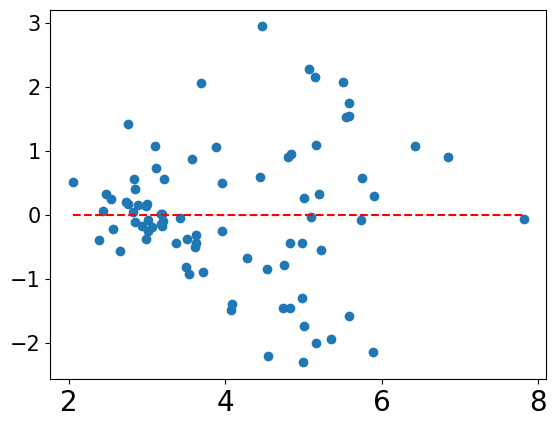

In [66]:
plt.scatter(m0.fittedvalues, m0.resid)
plt.hlines(y=0, xmin=min(m0.fittedvalues), xmax=max(m0.fittedvalues), colors='r', linestyles='dashed')
plt.show()

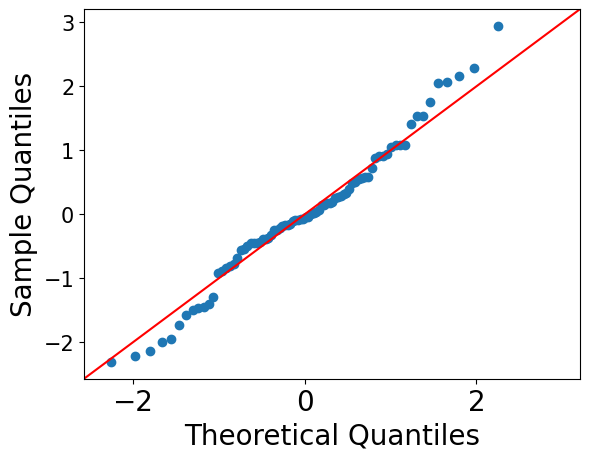

In [67]:
sm.qqplot(m0.resid, line="45")
plt.show()

In [68]:
anova_m0 = anova_lm(m0,typ=2) # IMPORTANT: use type 2 ANOVA to get the effect of each variable after accounting for the other variables in the model
anova_m0["partial_eta_sq"] = (
    anova_m0["sum_sq"] /
    (anova_m0["sum_sq"] + anova_m0.loc["Residual", "sum_sq"])
)
print(anova_m0)

                     sum_sq    df          F    PR(>F)  partial_eta_sq
C(thiamin)         9.683333   1.0   7.959657  0.006100        0.094803
C(salt)            9.833041   1.0   8.082716  0.005737        0.096128
C(carbon_source)  10.991048   1.0   9.034593  0.003588        0.106246
oa_yield          10.639498   1.0   8.745621  0.004134        0.103198
p_yield           30.725880   1.0  25.256538  0.000003        0.249431
Residual          92.457916  76.0        NaN       NaN        0.500000


## Model with interactions only: int_model

In [83]:
int_model = smf.ols(
    "log_sector ~ p_on_oa_competition + p_on_oa_facilitation + oa_on_p_competition + oa_on_p_facilitation",
    data=data_full
).fit()
print(int_model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_sector   R-squared:                       0.463
Model:                            OLS   Adj. R-squared:                  0.435
Method:                 Least Squares   F-statistic:                     16.58
Date:                Thu, 27 Aug 2026   Prob (F-statistic):           7.73e-10
Time:                        18:30:02   Log-Likelihood:                -129.42
No. Observations:                  82   AIC:                             268.8
Df Residuals:                      77   BIC:                             280.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                4.7317 

In [70]:
# Suprisingly the R² improves when we separate facilitation and competition
int_model_star = smf.ols(
    "log_sector ~ p_on_oa_facilitation + oa_on_p_facilitation + p_on_oa_competition + oa_on_p_competition",
    data=data_full
).fit()
print(int_model_star.summary())

                            OLS Regression Results                            
Dep. Variable:             log_sector   R-squared:                       0.463
Model:                            OLS   Adj. R-squared:                  0.435
Method:                 Least Squares   F-statistic:                     16.58
Date:                Thu, 27 Aug 2026   Prob (F-statistic):           7.73e-10
Time:                        16:15:37   Log-Likelihood:                -129.42
No. Observations:                  82   AIC:                             268.8
Df Residuals:                      77   BIC:                             280.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                4.7317 

In [71]:
anova_int = anova_lm(int_model,typ=2) # IMPORTANT: use type 2 ANOVA to get the effect of each variable after accounting for the other variables in the model
anova_int["partial_eta_sq"] = (
    anova_int["sum_sq"] /
    (anova_int["sum_sq"] + anova_int.loc["Residual", "sum_sq"])
)
print(anova_int)

              sum_sq    df         F    PR(>F)  partial_eta_sq
p_on_oa     1.401386   1.0  0.690407  0.408699        0.009244
oa_on_p    18.983331   1.0  9.352335  0.003099        0.112202
Residual  150.204890  74.0       NaN       NaN        0.500000


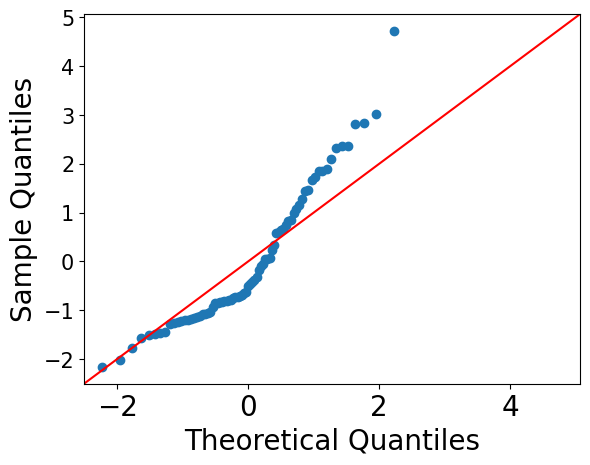

In [72]:
sm.qqplot(int_model.resid, line="45")
plt.show()

## Model with interactions and yields: model_int_yield

In [73]:
int_yield_model = smf.ols(
    "log_sector ~ p_on_oa + oa_on_p + p_yield + oa_yield",
    data=data_full
).fit()
print(int_yield_model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_sector   R-squared:                       0.755
Model:                            OLS   Adj. R-squared:                  0.741
Method:                 Least Squares   F-statistic:                     55.37
Date:                Thu, 27 Aug 2026   Prob (F-statistic):           3.03e-21
Time:                        16:15:37   Log-Likelihood:                -86.785
No. Observations:                  77   AIC:                             183.6
Df Residuals:                      72   BIC:                             195.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.8770      1.165      4.187      0.0

In [74]:
anova_int_yield = anova_lm(int_yield_model,typ=2) # IMPORTANT: use type 2 ANOVA to get the effect of each variable after accounting for the other variables in the model
anova_int_yield["partial_eta_sq"] = (
    anova_int_yield["sum_sq"] /
    (anova_int_yield["sum_sq"] + anova_int_yield.loc["Residual", "sum_sq"])
)
print(anova_int_yield)

             sum_sq    df           F        PR(>F)  partial_eta_sq
p_on_oa    4.838853   1.0    8.111361  5.729725e-03        0.101251
oa_on_p   27.375305   1.0   45.889177  2.875936e-09        0.389257
p_yield   59.675058   1.0  100.033201  2.932913e-15        0.581476
oa_yield   7.650199   1.0   12.824016  6.179355e-04        0.151184
Residual  42.951782  72.0         NaN           NaN        0.500000


## Full model: model_full

In [75]:
# Try full model
model_full = smf.ols(
    "log_sector ~ C(thiamin) + C(salt) + C(carbon_source) + p_on_oa + oa_on_p + p_yield + oa_yield",
    data=data_full
).fit()
print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:             log_sector   R-squared:                       0.768
Model:                            OLS   Adj. R-squared:                  0.744
Method:                 Least Squares   F-statistic:                     32.60
Date:                Thu, 27 Aug 2026   Prob (F-statistic):           1.66e-19
Time:                        16:15:37   Log-Likelihood:                -84.660
No. Observations:                  77   AIC:                             185.3
Df Residuals:                      69   BIC:                             204.1
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               -14.12

In [76]:
anova_full = anova_lm(model_full,typ=2) # IMPORTANT: use type 2 ANOVA to get the effect of each variable after accounting for the other variables in the model
anova_full["partial_eta_sq"] = (
    anova_full["sum_sq"] /
    (anova_full["sum_sq"] + anova_full.loc["Residual", "sum_sq"])
)
print(anova_full)

                     sum_sq    df          F        PR(>F)  partial_eta_sq
C(thiamin)         2.128635   1.0   3.613616  6.148571e-02        0.049765
C(salt)            0.004510   1.0   0.007656  9.305274e-01        0.000111
C(carbon_source)   2.274847   1.0   3.861829  5.342349e-02        0.053002
p_on_oa            3.898701   1.0   6.618517  1.224702e-02        0.087525
oa_on_p           21.863981   1.0  37.116757  5.611375e-08        0.349773
p_yield           50.711636   1.0  86.089150  9.315754e-14        0.555095
oa_yield           2.646543   1.0   4.492828  3.763703e-02        0.061133
Residual          40.645109  69.0        NaN           NaN        0.500000


## Model with thiamin, competition, Oa on partner, yields

In [77]:
# Try maybe best model
model_maybe_best = smf.ols(
    "log_sector ~ C(thiamin) + p_on_oa_competition + oa_on_p + p_yield + oa_yield",
    data=data_full
).fit()
print(model_maybe_best.summary())

                            OLS Regression Results                            
Dep. Variable:             log_sector   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     45.05
Date:                Thu, 27 Aug 2026   Prob (F-statistic):           1.06e-20
Time:                        16:15:37   Log-Likelihood:                -85.882
No. Observations:                  77   AIC:                             183.8
Df Residuals:                      71   BIC:                             197.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               6.0701    

In [78]:
anova_maybe_best = anova_lm(model_maybe_best, typ=2) # IMPORTANT: use type 2 ANOVA to get the effect of each variable after accounting for the other variables in the model
anova_maybe_best["partial_eta_sq"] = (
    anova_maybe_best["sum_sq"] /
    (anova_maybe_best["sum_sq"] + anova_maybe_best.loc["Residual", "sum_sq"])
)
print(anova_maybe_best)

                        sum_sq    df          F        PR(>F)  partial_eta_sq
C(thiamin)            0.008160   1.0   0.013809  9.067871e-01        0.000194
p_on_oa_competition   5.590607   1.0   9.460714  2.980023e-03        0.117582
oa_on_p              23.597808   1.0  39.933429  2.025743e-08        0.359977
p_yield              48.413943   1.0  81.928572  1.886332e-13        0.535731
oa_yield              0.600057   1.0   1.015447  3.170233e-01        0.014100
Residual             41.955936  71.0        NaN           NaN        0.500000


## Nested models: environmental factors vs interactions

In [79]:
# carbon source and salt
m_cs_s = smf.ols(
    "log_sector ~ C(carbon_source)+C(salt)",
    data=data_full
).fit()

# carbon source, salt and thiamin
m_cs_s_t = smf.ols(
    "log_sector ~ C(carbon_source)+C(salt)+C(thiamin)",
    data=data_full
).fit()

# carbon source, salt, thiamin and p_on_oa
m_env_i1 = smf.ols(
    "log_sector ~ C(carbon_source)+C(salt)+C(thiamin)+p_on_oa",
    data=data_full
).fit()

# carbon source, salt, thiamin, p_on_oa_competition
m_env_c1 = smf.ols(
    "log_sector ~ C(carbon_source)+C(salt)+C(thiamin)+p_on_oa_competition",
    data=data_full
).fit()

# carbon source, salt, thiamin, p_on_oa_facilitation
m_env_f1 = smf.ols(
    "log_sector ~ C(carbon_source)+C(salt)+C(thiamin)+p_on_oa_facilitation",
    data=data_full
).fit()

# carbon source, salt, thiamin, p_on_oa and oa_on_p
m_env_i2 = smf.ols(
    "log_sector ~ C(carbon_source)+C(salt)+C(thiamin)+p_on_oa+oa_on_p",
    data=data_full
).fit()

# carbon source, salt, thiamin, p_on_oa_competition and oa_on_p_competition
m_env_c2 = smf.ols(
    "log_sector ~ C(carbon_source)+C(salt)+C(thiamin)+p_on_oa_competition+oa_on_p_competition",
    data=data_full
).fit()

## carbon source, salt, thiamin, p_on_oa_facilitation and oa_on_p_facilitation
m_env_f2 = smf.ols(
    "log_sector ~ C(carbon_source)+C(salt)+C(thiamin)+p_on_oa_facilitation+oa_on_p_facilitation",
    data=data_full
).fit()

In [80]:
# # compare environment with interaction models
anova_lm(m_cs_s, m_cs_s_t, m_env_i1, m_env_i2)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,79.0,179.860314,0.0,NaN,NaN,NaN
1,78.0,133.970786,1.0,45.889528,33.596686,1.369776e-07
2,77.0,111.695948,1.0,22.274838,16.307876,1.262183e-04
3,71.0,96.978507,6.0,14.717441,1.795825,1.122534e-01


In [81]:
# # compare environment with facilitation models
anova_lm(m_cs_s_t, m_env_f1, m_env_f2)


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,78.0,133.970786,0.0,NaN,NaN,NaN
1,77.0,133.867912,1.0,0.102874,0.058979,0.808764
2,76.0,132.564543,1.0,1.303369,0.747229,0.390075


In [82]:
# # compare environment with competition models
anova_lm(m_cs_s_t, m_env_c1, m_env_c2)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,78.0,133.970786,0.0,NaN,NaN,NaN
1,77.0,97.076110,1.0,36.894676,30.017913,5.200089e-07
2,76.0,93.410739,1.0,3.665371,2.982186,8.824806e-02
